In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("harrimansaragih/dummy-advertising-and-sales-data")

print("Path to dataset files:", path)

100%|██████████| 92.7k/92.7k [00:00<00:00, 18.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/harrimansaragih/dummy-advertising-and-sales-data/versions/1


**Data Preparation - Exploration stage**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

df = pd.read_csv(path + "/Dummy Data HSS.csv")
print("Shape:", df.shape)
df.head(10)

Shape: (4572, 5)


,TV,Radio,Social Media,Influencer,Sales
0,16.0,6.566231,2.907983,Mega,54.732757
1,13.0,9.237765,2.409567,Mega,46.677897
2,41.0,15.886446,2.913410,Mega,150.177829
3,83.0,30.020028,6.922304,Mega,298.246340
4,15.0,8.437408,1.405998,Micro,56.594181
5,29.0,9.614382,1.027163,Mega,105.889148
6,55.0,24.893811,4.273602,Micro,198.679825
7,31.0,17.355042,2.289855,Nano,108.733932
8,76.0,24.648898,7.130116,Macro,270.189400
9,13.0,0.431128,2.229423,Mega,48.280582


In [ ]:
#quality check
# Types, missing values, duplicates, category labels, summary statistics
print(df.dtypes, "\n")
print("Duplicate rows:", df.duplicated().sum())
print("Rows with at least one missing value:", df.isna().any(axis=1).sum())
print("Rows with more than one missing value:", (df.isna().sum(axis=1) > 1).sum(), "\n")
print("Missing values per column:\n", df.isna().sum(), "\n")
print("Influencer categories:", df["Influencer"].value_counts().to_dict(), "\n")
df.describe().round(2)

TV              float64
Radio           float64
Social Media    float64
Influencer       object
Sales           float64
dtype: object 

Duplicate rows: 0
Rows with at least one missing value: 26
Rows with more than one missing value: 0 

Missing values per column:
 TV              10
Radio            4
Social Media     6
Influencer       0
Sales            6
dtype: int64 

Influencer categories: {'Mega': 1158, 'Micro': 1153, 'Nano': 1139, 'Macro': 1122} 



,TV,Radio,Social Media,Sales
count,4562.00,4568.00,4566.00,4566.00
mean,54.07,18.16,3.32,192.47
std,26.13,9.68,2.21,93.13
min,10.00,0.00,0.00,31.20
25%,32.00,10.53,1.53,112.32
50%,53.00,17.86,3.06,189.23
75%,77.00,25.65,4.81,272.51
max,100.00,48.87,13.98,364.08


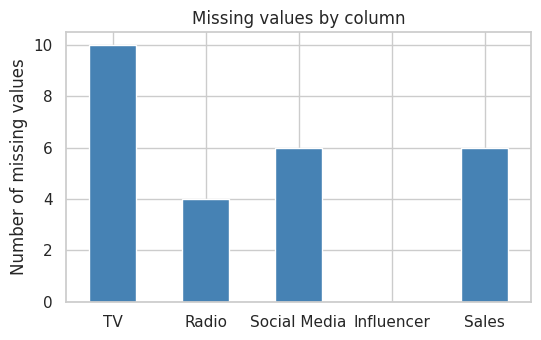

In [ ]:
# Missing values chart
ax = df.isna().sum().plot(kind="bar", color="steelblue", figsize=(6, 3.5))
ax.set_ylabel("Number of missing values"); ax.set_title("Missing values by column")
plt.xticks(rotation=0); plt.show()

In [ ]:
# Cleaning: drop the rows with a missing value, then check the data did not change shape
clean = df.dropna().reset_index(drop=True)
removed = len(df) - len(clean)
print(f"Rows before: {len(df)} | after: {len(clean)} | removed: {removed} ({removed/len(df):.2%})")

# Compare means and standard deviations before and after cleaning
pd.concat([df.describe().loc[["mean", "std"]], clean.describe().loc[["mean", "std"]]],
          keys=["before", "after"]).round(2)

Rows before: 4572 | after: 4546 | removed: 26 (0.57%)


TV  Radio  Social Media   Sales
before mean  54.07  18.16          3.32  192.47
       std   26.13   9.68          2.21   93.13
after  mean  54.06  18.16          3.32  192.41
       std   26.10   9.66          2.21   93.02

**Interpretation (missing values):** A bar chart is a fast way to see where the gaps are. Only 26 of 4,572 rows (0.6%) have a missing value, spread across `TV`, `Radio`, `Social Media` and `Sales`, and no row is missing more than one. Since so few rows are affected (and rows without `Sales` cannot be used for training anyway), I dropped them; the before/after table shows the means and standard deviations are essentially unchanged (for example mean `Sales` 192.47 vs. 192.41). There are no duplicate rows and the four `Influencer` labels are consistent with roughly equal counts.

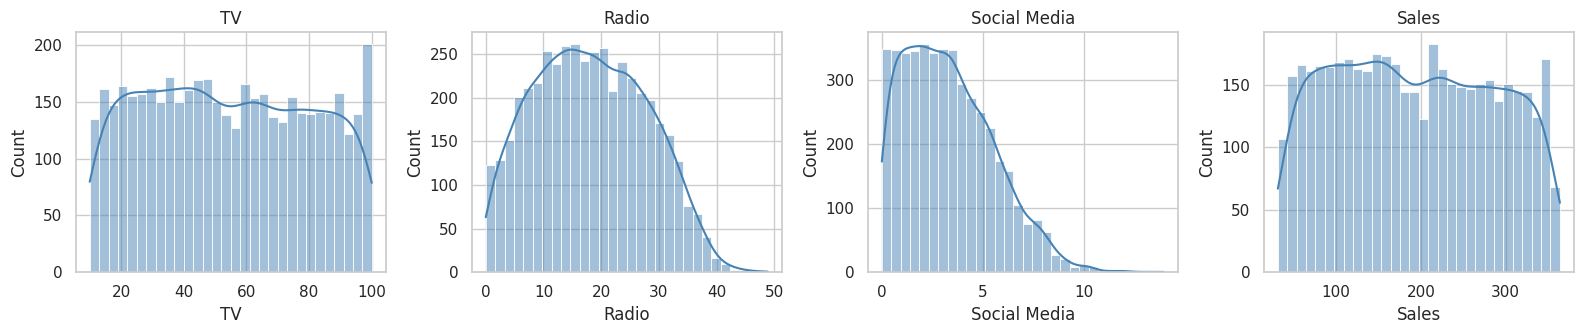

,skew,IQR outliers
TV,0.07,0
Radio,0.14,1
Social Media,0.65,28
Sales,0.07,0


In [ ]:
#distributions and outliers
num_cols = ["TV", "Radio", "Social Media", "Sales"]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, c in zip(axes, num_cols):
    sns.histplot(clean[c], bins=30, kde=True, ax=ax, color="steelblue")
    ax.set_title(c)
plt.tight_layout(); plt.show()

# Skewness and number of outliers by the 1.5 x IQR rule
summary = pd.DataFrame({"skew": clean[num_cols].skew()})
q1, q3 = clean[num_cols].quantile(0.25), clean[num_cols].quantile(0.75)
iqr = q3 - q1
summary["IQR outliers"] = ((clean[num_cols] < q1 - 1.5 * iqr) | (clean[num_cols] > q3 + 1.5 * iqr)).sum()
summary.round(2)

**Interpretation:** Histograms show the shape of each variable and any skew, which helps with choosing which model to use and spotting the unusual values. `TV` and `Sales` are spread broadly across their ranges with almost no skew, and `Radio` is close to symmetric (skew 0.14). `Social Media` is mildly right-skewed (skew 0.65) and has 28 high values flagged by the 1.5 x IQR rule; these are plausible large budgets rather than errors, so I keep them.

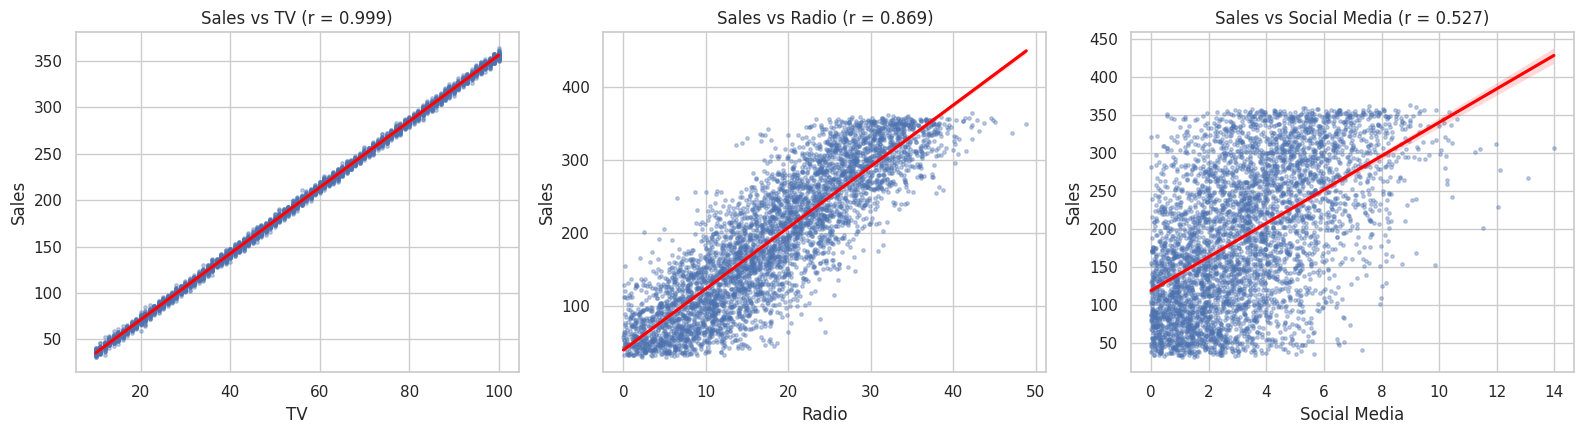

In [ ]:
#relationships between variables
# Sales vs each numeric predictor
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, c in zip(axes, ["TV", "Radio", "Social Media"]):
    sns.regplot(data=clean, x=c, y="Sales", ax=ax, scatter_kws={"s": 6, "alpha": 0.35},
                line_kws={"color": "red"})
    r = clean[c].corr(clean["Sales"])          # Pearson correlation coefficient
    ax.set_title(f"Sales vs {c} (r = {r:.3f})")
plt.tight_layout(); plt.show()

**Interpretation (scatterplots):** Scatterplots are the right plot for numeric-vs-numeric relationships because they show the shape of the relationship, not just its strength. `Sales` rises along an almost perfectly straight line with `TV` (r about 0.999), shows a positive but much more scattered pattern with `Radio` (r about 0.87), and a weaker one with `Social Media` (r about 0.53). The straight-line pattern with constant spread supports using linear regression.


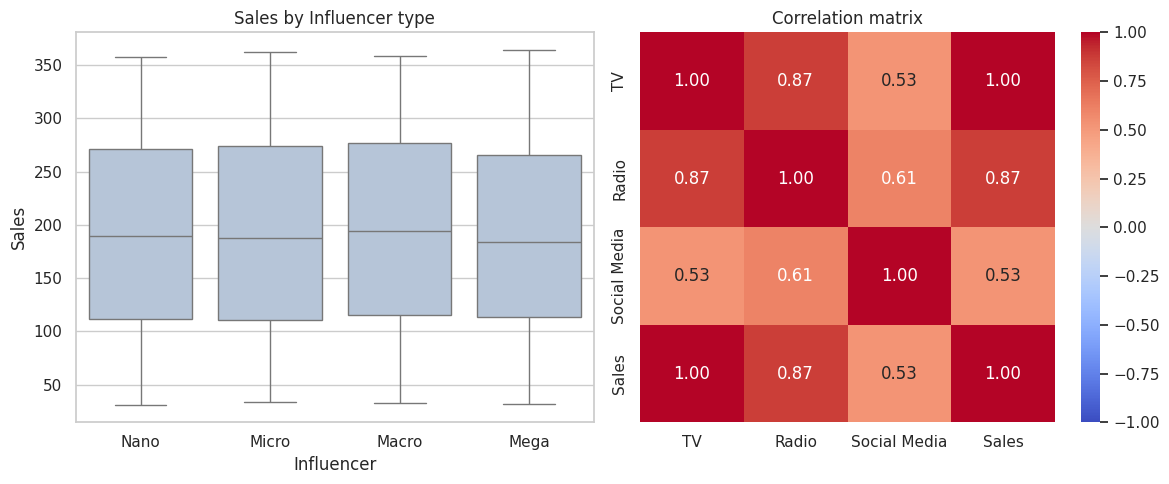

,count,mean,std
Influencer,,,
Macro,1112,196.1,92.4
Mega,1152,190.4,92.3
Micro,1148,191.6,94.1
Nano,1134,191.7,93.3


In [ ]:
# Sales by influencer type
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=clean, x="Influencer", y="Sales", order=["Nano", "Micro", "Macro", "Mega"],
            ax=axes[0], color="lightsteelblue")
axes[0].set_title("Sales by Influencer type")

# Correlation heatmap of the numeric variables
sns.heatmap(clean[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Correlation matrix")
plt.tight_layout(); plt.show()

clean.groupby("Influencer")["Sales"].agg(["count", "mean", "std"]).round(1)

**Interpretation (boxplot and heatmap):** A boxplot compares the distribution of `Sales` across the four influencer types, and the heatmap summarises all pairwise correlations. The four influencer types have nearly identical medians, spreads and mean `Sales` (about 190 to 196), so `Influencer` shows no visible effect. The heatmap also shows `Radio` and `Social Media` are themselves correlated with `TV` (0.87 and 0.53), meaning budgets tend to rise together, so their link with `Sales` may be only indirect.

**Regression Analysis - Execution stage**

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

y = clean["Sales"]
# One-hot encode Influencer; drop_first makes "Macro" the reference group
X_all = pd.get_dummies(clean[["TV", "Radio", "Social Media", "Influencer"]],
                       columns=["Influencer"], drop_first=True, dtype=float)

# 80/20 train-test split with a fixed seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "| Test:", X_test.shape)

feature_sets = {
    "M1: TV only": ["TV"],
    "M2: TV + Radio": ["TV", "Radio"],
    "M3: TV + Radio + Social Media": ["TV", "Radio", "Social Media"],
    "M4: M3 + Influencer": list(X_all.columns),
}

Train: (3636, 6) | Test: (910, 6)


In [ ]:
# Baseline: predict the mean of the training Sales
base = np.full(len(y_test), y_train.mean())
rows = [{"Model": "Baseline (mean)", "Train R2": 0.0, "Train adj R2": 0.0,
         "Test R2": r2_score(y_test, base), "Test RMSE": mean_squared_error(y_test, base) ** 0.5,
         "Test MAE": mean_absolute_error(y_test, base), "5-fold CV R2": np.nan}]

for name, cols in feature_sets.items():
    m = LinearRegression().fit(X_train[cols], y_train)
    pred_tr, pred_te = m.predict(X_train[cols]), m.predict(X_test[cols])
    n, k = len(y_train), len(cols)
    r2_tr = r2_score(y_train, pred_tr)
    rows.append({"Model": name,
                 "Train R2": r2_tr,
                 "Train adj R2": 1 - (1 - r2_tr) * (n - 1) / (n - k - 1),  # penalises extra predictors
                 "Test R2": r2_score(y_test, pred_te),
                 "Test RMSE": mean_squared_error(y_test, pred_te) ** 0.5,
                 "Test MAE": mean_absolute_error(y_test, pred_te),
                 "5-fold CV R2": cross_val_score(LinearRegression(), X_train[cols], y_train, cv=5, scoring="r2").mean()})

comparison = pd.DataFrame(rows).set_index("Model").round(4)
comparison

,Train R2,Train adj R2,Test R2,Test RMSE,Test MAE,5-fold CV R2
Model,,,,,,
Baseline (mean),0.000,0.000,-0.0002,91.7197,79.5440,NaN
M1: TV only,0.999,0.999,0.9990,2.8833,2.3109,0.999
M2: TV + Radio,0.999,0.999,0.9990,2.8834,2.3107,0.999
M3: TV + Radio + Social Media,0.999,0.999,0.9990,2.8847,2.3115,0.999
M4: M3 + Influencer,0.999,0.999,0.9990,2.8849,2.3129,0.999


**Reading the table**: All four models reach a test R² of about 0.999, and RMSE and MAE barely change from M1 to M4 (RMSE 2.88 to 2.89), compared with an RMSE of about 92 for the mean-only baseline. Adjusted R² does not increase when `Radio`, `Social Media` or `Influencer` are added, so they add no explanatory power. Train, test and cross-validated R² agree, so there is no sign of overfitting. The next step is to check why the extra predictors do not help.

In [ ]:
# OLS summaries with statsmodels, fitted on the training data
import statsmodels.api as sm

# add_constant adds the intercept column
m1 = sm.OLS(y_train, sm.add_constant(X_train[feature_sets["M1: TV only"]])).fit()
m4 = sm.OLS(y_train, sm.add_constant(X_train[feature_sets["M4: M3 + Influencer"]])).fit()

print(m1.summary())   # M1: TV only
print(m4.summary())   # M4: all predictors (coefficients, p-values, 95% confidence intervals, F-statistic)

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 3.598e+06
Date:                Sun, 04 Oct 2026   Prob (F-statistic):               0.00
Time:                        00:55:30   Log-Likelihood:                -9110.9
No. Observations:                3636   AIC:                         1.823e+04
Df Residuals:                    3634   BIC:                         1.824e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1690      0.113     -1.500      0.1

In [ ]:
# Multicollinearity: variance inflation factor = 1 / (1 - R2 of that predictor regressed on the others)
def vif(cols):
    out = {}
    for c in cols:
        others = [o for o in cols if o != c]
        r2 = LinearRegression().fit(X_train[others], X_train[c]).score(X_train[others], X_train[c])
        out[c] = 1 / (1 - r2)
    return pd.Series(out).round(2)

print(vif(["TV", "Radio", "Social Media"]).to_frame("VIF"))

# Does adding predictors reduce the error significantly? Nested F-tests on the training data
def rss(cols):
    m = LinearRegression().fit(X_train[cols], y_train)
    return ((y_train - m.predict(X_train[cols])) ** 2).sum()

def f_test(small, big):
    s, b = feature_sets[small], feature_sets[big]
    n, df_num = len(y_train), len(b) - len(s)
    F = ((rss(s) - rss(b)) / df_num) / (rss(b) / (n - len(b) - 1))
    return round(F, 3), round(stats.f.sf(F, df_num, n - len(b) - 1), 3)

print("\nF-test M1 vs M3 (add Radio + Social Media): F, p =", f_test("M1: TV only", "M3: TV + Radio + Social Media"))
print("F-test M3 vs M4 (add Influencer): F, p =", f_test("M3: TV + Radio + Social Media", "M4: M3 + Influencer"))

               VIF
TV            4.08
Radio         4.65
Social Media  1.57

F-test M1 vs M3 (add Radio + Social Media): F, p = (np.float64(0.224), np.float64(0.8))
F-test M3 vs M4 (add Influencer): F, p = (np.float64(0.254), np.float64(0.858))


**Interpretation:**`TV` is overwhelmingly significant in both models (t = 1,897 in the TV-only model M1 and t = 939 in the full model M4, p < 0.001), and each extra unit of TV budget is associated with about 3.56 more units of `Sales` (95% CI 3.558 to 3.566 in M1). In the full model, `Radio` (p = 0.814), `Social Media` (p = 0.604) and the `Influencer` dummies (all p above 0.5) are not significant, and their 95% confidence intervals include 0. The VIFs for `TV` and `Radio` (about 4.1 and 4.6) show that these two predictors overlap: the standard error of the `TV` coefficient roughly doubles, from 0.002 in M1 to 0.004 in M4. The nested F-tests agree: adding `Radio` and `Social Media` (p = 0.80) or `Influencer` (p = 0.86) does not reduce the error significantly. `Radio` looked useful in the scatterplot only because it moves with `TV`. I therefore choose the simplest model, M1 (`TV` only), as the final model.

Final model: Sales = -0.169 + 3.562 x TV
Test R2 = 0.9990 | RMSE = 2.883 | MAE = 2.311
Test set size: 910 | Mean residual: 0.075 | Residual skewness: 0.001 | Excess kurtosis: -0.119


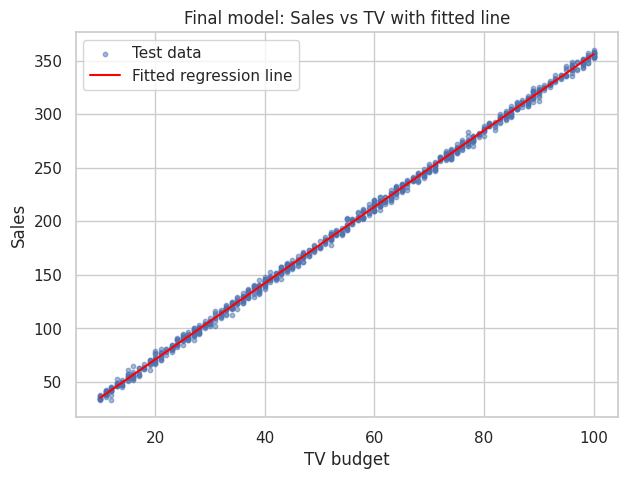

In [ ]:
final_cols = ["TV"]
final = LinearRegression().fit(X_train[final_cols], y_train)
pred = final.predict(X_test[final_cols])
resid = y_test - pred

print(f"Final model: Sales = {final.intercept_:.3f} + {final.coef_[0]:.3f} x TV")
print(f"Test R2 = {r2_score(y_test, pred):.4f} | RMSE = {mean_squared_error(y_test, pred) ** 0.5:.3f} | MAE = {mean_absolute_error(y_test, pred):.3f}")
print(f"Test set size: {len(y_test)} | Mean residual: {resid.mean():.3f} | Residual skewness: {resid.skew():.3f} | Excess kurtosis: {resid.kurt():.3f}")

# Fitted line on the test data
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_test["TV"], y_test, s=10, alpha=0.5, label="Test data")
xs = np.linspace(clean["TV"].min(), clean["TV"].max(), 100)
ax.plot(xs, final.intercept_ + final.coef_[0] * xs, color="red", label="Fitted regression line")
ax.set_xlabel("TV budget"); ax.set_ylabel("Sales"); ax.set_title("Final model: Sales vs TV with fitted line")
ax.legend(); plt.show()

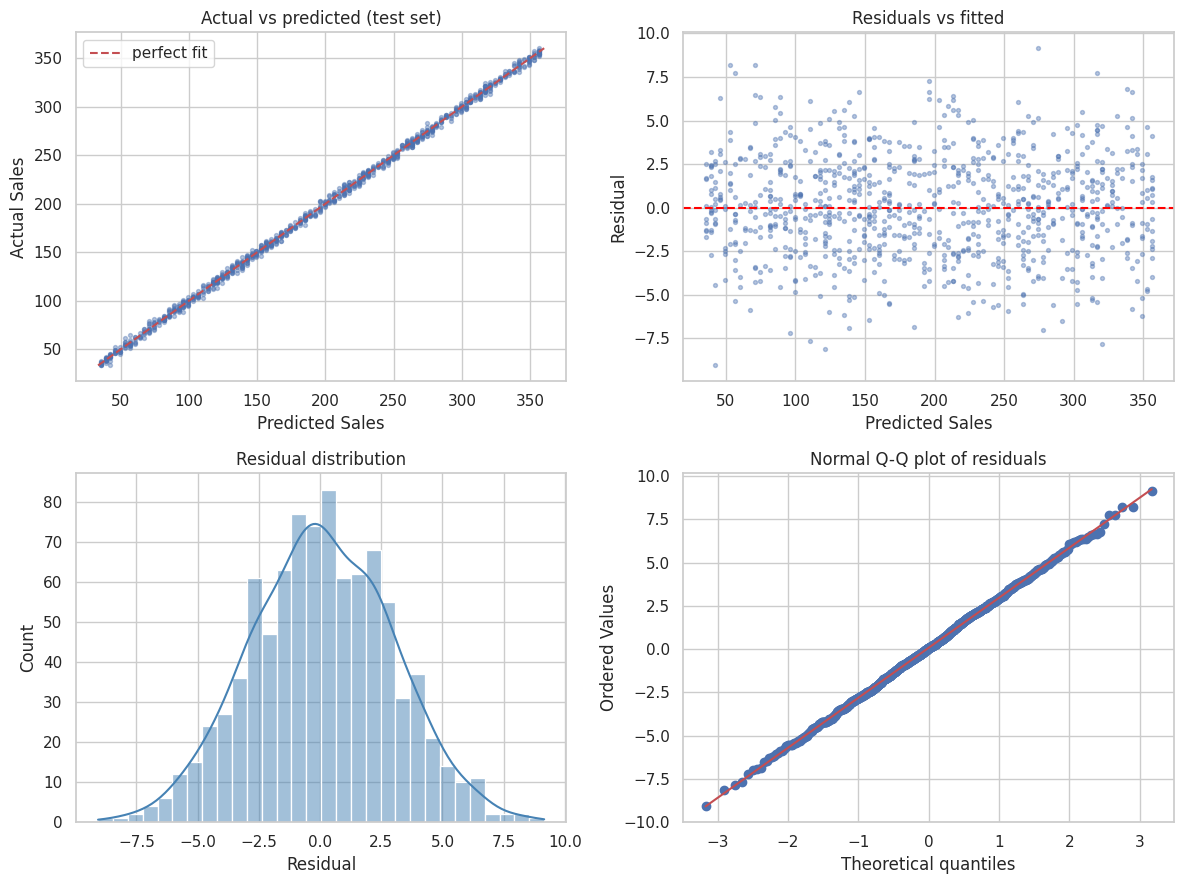

In [ ]:
# Residual diagnostics
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].scatter(pred, y_test, s=8, alpha=0.4)
lims = [y_test.min(), y_test.max()]
axes[0, 0].plot(lims, lims, "r--", label="perfect fit")
axes[0, 0].set(xlabel="Predicted Sales", ylabel="Actual Sales", title="Actual vs predicted (test set)")
axes[0, 0].legend()

axes[0, 1].scatter(pred, resid, s=8, alpha=0.4)
axes[0, 1].axhline(0, color="red", ls="--")
axes[0, 1].set(xlabel="Predicted Sales", ylabel="Residual", title="Residuals vs fitted")

sns.histplot(resid, bins=30, kde=True, ax=axes[1, 0], color="steelblue")
axes[1, 0].set(xlabel="Residual", title="Residual distribution")

stats.probplot(resid, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Normal Q-Q plot of residuals")
plt.tight_layout(); plt.show()

**Interpretation.** The fitted line passes straight through the cloud of test points, and the actual-vs-predicted plot hugs the red 45-degree line, so the model fits very well across the whole range. Residuals form a flat horizontal band centred on 0 with no curve (linearity holds) and no funnel (constant variance holds), their histogram is bell-shaped, and the Q-Q plot follows the straight line (approximately normal). Residual skewness and kurtosis are both close to 0. All the OLS assumptions look satisfied, so the coefficient estimates, confidence intervals and p-values can be trusted.